In [1]:
from google.colab import files

uploaded = files.upload()

Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
file_path = next(iter(uploaded))

df = pd.read_csv(file_path)

df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
df.shape

(64295, 5)

In [6]:
df.replace('nan',np.nan,inplace=True)

In [19]:
df.dropna(inplace=True,how='any')

In [20]:
df.shape

(37427, 5)

In [21]:
df.dropna(inplace=True,how='all')

In [22]:
df.shape

(37427, 5)

In [23]:
X = df['Translated_Review']
y = df['Sentiment']

In [24]:
y.value_counts()

,count
Sentiment,
Positive,23998
Negative,8271
Neutral,5158


<function matplotlib.pyplot.show(close=None, block=None)>

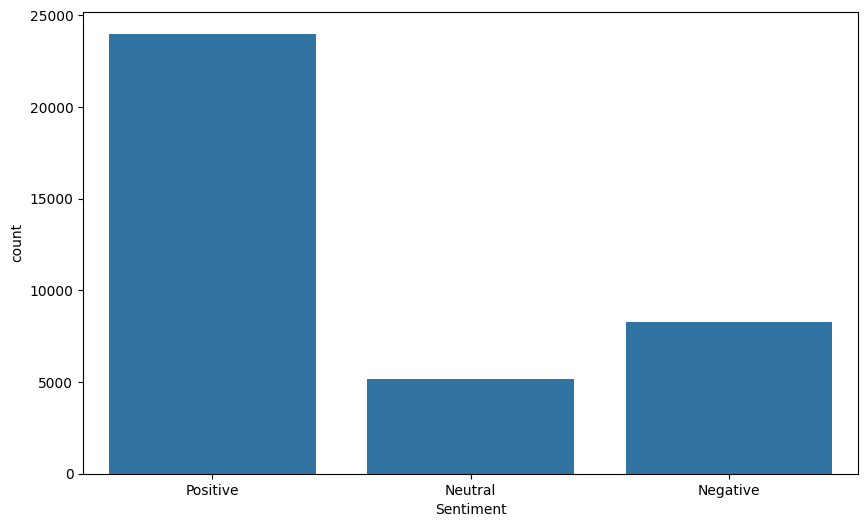

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(x=y)
plt.show

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [27]:
X_train, X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModel

In [29]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    max_features=None,
    ngram_range=(1, 1),
    min_df=1,
    max_df=1.0
)

In [30]:
X_train_tdidf = vectorizer.fit_transform(X_train)
X_test_tdidf = vectorizer.transform(X_test)

In [31]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_tdidf,y_train)

naive_predictions = naive_bayes.predict(X_test_tdidf)

In [33]:
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train_tdidf,y_train)

logistic_predictions = logistic_regression.predict(X_test_tdidf)

In [34]:
import torch

tokenizer = AutoTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')
model = AutoModel.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  669MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
inputs = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    return_tensors='pt'
)


In [ ]:
with torch.no_grad():
  outputs = model(**inputs)

In [ ]:
 X_train_embeddings = outputs.last_hidden_state[:, 0, :]